In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout

In [3]:
Electric = pd.read_csv("household_power_consumption.txt",sep = ";",low_memory=False, na_values = ['?'])

In [4]:
Electric.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
Electric.shape

(2075259, 9)

In [5]:
Electric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [6]:
Electric.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [7]:
Electric["Datetime"] = pd.to_datetime(Electric["Date"]+" " + Electric["Time"], dayfirst=True)

In [8]:
Electric = Electric[["Datetime", "Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]]

In [9]:
Electric["Global_active_power"] = Electric["Global_active_power"].astype(float)
Electric["Global_reactive_power"] = Electric["Global_reactive_power"].astype(float)
Electric["Voltage"] = Electric["Voltage"].astype(float)
Electric["Global_intensity"] = Electric["Global_intensity"].astype(float)
Electric["Sub_metering_1"] = Electric["Sub_metering_1"].astype(float)
Electric["Sub_metering_2"] = Electric["Sub_metering_2"].astype(float)
Electric["Sub_metering_3"] = Electric["Sub_metering_3"].astype(float)

In [10]:
Electric ["Global_active_power"] = Electric ["Global_active_power"].interpolate()
Electric ["Global_reactive_power"] = Electric ["Global_reactive_power"].interpolate() 
Electric ["Voltage"] = Electric ["Voltage"].interpolate()
Electric ["Global_intensity"] = Electric ["Global_intensity"].interpolate()
Electric ["Sub_metering_1"] = Electric ["Sub_metering_1"].interpolate()
Electric ["Sub_metering_2"] = Electric ["Sub_metering_2"].interpolate()
Electric ["Sub_metering_3"] = Electric ["Sub_metering_3"].interpolate()

In [11]:
Electric.isnull().sum()

Datetime                 0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [12]:
Electric = Electric.dropna()

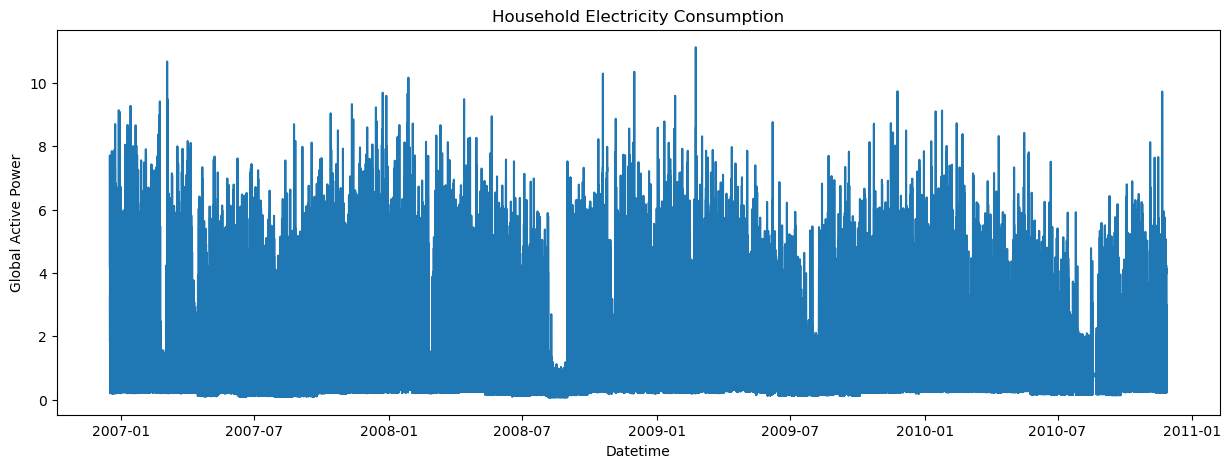

In [13]:
plt.figure(figsize=(15, 5))
plt.plot(Electric["Datetime"], Electric["Global_active_power"])
plt.xlabel("Datetime")
plt.ylabel("Global Active Power")
plt.title("Household Electricity Consumption")
plt.show()

In [14]:
Electric = Electric.set_index("Datetime")
hourly_data = Electric [["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]].resample("H").mean()
hourly_data = hourly_data.interpolate()
hourly_data.head()

C:\Users\SIMON\AppData\Local\Temp\ipykernel_19568\798209431.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = Electric [["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]].resample("H").mean()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [15]:
data = hourly_data.values.reshape(-1, 1)

In [16]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [26]:
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sequences(scaled_data, sequence_length=24)

print("X shape:", X.shape)
print("y shape:", y.shape)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X shape: (242099, 24, 1)
y shape: (242099, 1)
X_train shape: (193679, 24, 1)
X_test shape: (48420, 24, 1)
y_train shape: (193679, 1)
y_test shape: (48420, 1)


In [27]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(
    SimpleRNN(32)
)

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

rnn_model.compile(optimizer="adam",loss="mean_squared_error", metrics=["mean_absolute_error"])

rnn_model.summary()

c:\Users\SIMON\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 24, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 61s 22ms/step - loss: 0.0073 - mean_absolute_error: 0.0548 - val_loss: 2.4729e-04 - val_mean_absolute_error: 0.0104
Epoch 2/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step - loss: 0.0020 - mean_absolute_error: 0.0319 - val_loss: 3.8592e-04 - val_mean_absolute_error: 0.0153
Epoch 3/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 0.0018 - mean_absolute_error: 0.0297 - val_loss: 3.1494e-04 - val_mean_absolute_error: 0.0118
Epoch 4/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 0.0015 - mean_absolute_error: 0.0266 - val_loss: 2.3994e-04 - val_mean_absolute_error: 0.0097
Epoch 5/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 0.0013 - mean_absolute_error: 0.0245 - val_loss: 3.5433e-04 - val_mean_absolute_error: 0.0130
Epoch 6/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 0.0013 - mean_absolute_error: 0.0238 - val_loss: 3.0712e-04 - val_mean_absolute_error: 0.0132
Epoch 7/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/s

In [29]:
rnn_predictions = rnn_model.predict(X_test)

1514/1514 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step


In [30]:
rnn_predictions_original = scaler.inverse_transform(rnn_predictions)
y_test_original = scaler.inverse_transform(y_test)

In [32]:
lstm_model = Sequential()
lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)
lstm_model.add(Dropout(0.2))
lstm_model.add(
    LSTM(32)
)
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 92s 33ms/step - loss: 0.0084 - val_loss: 2.9806e-04
Epoch 2/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 91s 33ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 3/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 92s 34ms/step - loss: 0.0016 - val_loss: 2.9735e-04
Epoch 4/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 96s 35ms/step - loss: 0.0012 - val_loss: 3.0280e-04
Epoch 5/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 100s 36ms/step - loss: 0.0013 - val_loss: 2.4530e-04
Epoch 6/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 91s 33ms/step - loss: 0.0012 - val_loss: 7.3050e-04
Epoch 7/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 95s 35ms/step - loss: 0.0012 - val_loss: 2.7327e-04
Epoch 8/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 101s 37ms/step - loss: 0.0012 - val_loss: 3.1280e-04
Epoch 9/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 94s 35ms/step - loss: 0.0012 - val_loss: 2.5833e-04
Epoch 10/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 94s 34ms/step - loss: 0.0011 - val_loss: 2.0471e-04


In [34]:
lstm_predictions = lstm_model.predict(X_test)
lstm_predictions_original = scaler.inverse_transform(lstm_predictions)

1514/1514 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step


In [35]:
rnn_mae = mean_absolute_error(y_test_original, rnn_predictions_original)

In [41]:
print("RNN MAE :", rnn_mae)

RNN MAE : 2.462590456008911


In [42]:
lstm_mae = mean_absolute_error(y_test_original, lstm_predictions_original)

In [43]:
print("LSTM MAE :", lstm_mae)

LSTM MAE : 1.9250810146331787


In [44]:
rnn_rmse = np.sqrt(mean_squared_error(y_test_original, rnn_predictions_original))

In [45]:
print("RNN RMSE:", rnn_rmse)

RNN RMSE: 3.638336641243447


In [46]:
lstm_rmse = np.sqrt(mean_squared_error(y_test_original, lstm_predictions_original))

In [47]:
print("LSTM RMSE:", lstm_rmse)

LSTM RMSE: 3.1508825004459005


In [50]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "MAE": [rnn_mae, lstm_mae],
    "RMSE": [rnn_rmse, lstm_rmse]
})
results

,Model,MAE,RMSE
0,RNN,2.462590,3.638337
1,LSTM,1.925081,3.150883


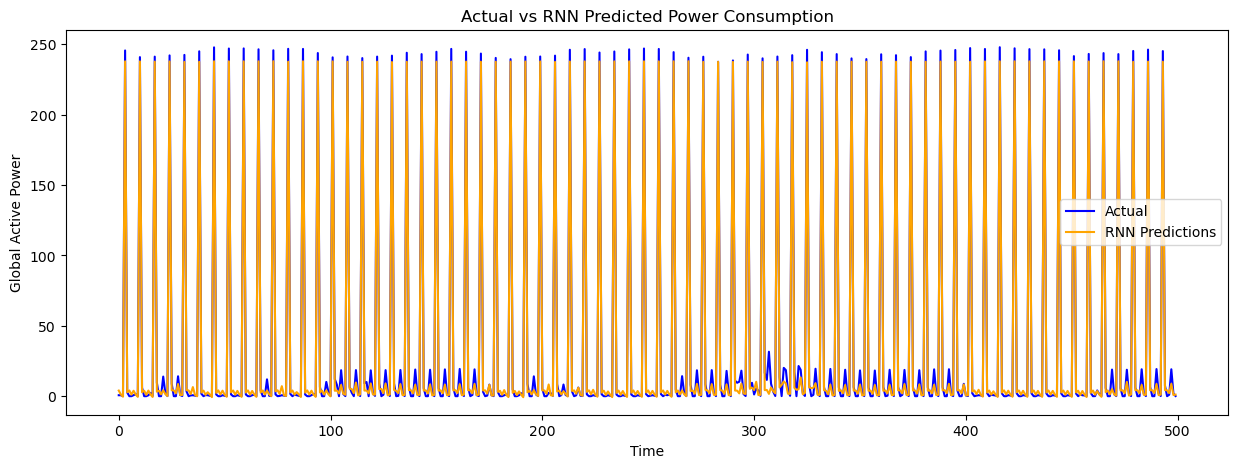

In [53]:
plt.figure(figsize=(15,5))
plt.plot(y_test_original[:500], label="Actual", color="blue")
plt.plot(rnn_predictions_original[:500], label="RNN Predictions", color="orange")
plt.title("Actual vs RNN Predicted Power Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

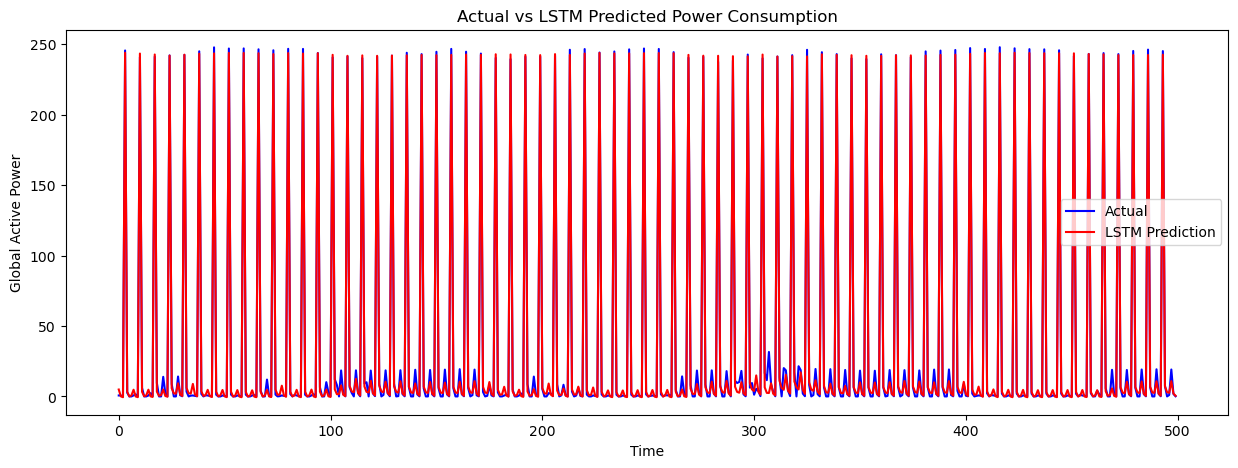

In [55]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_original[:500],label="Actual", color="blue")
plt.plot(lstm_predictions_original[:500],label="LSTM Prediction", color="red")
plt.title("Actual vs LSTM Predicted Power Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

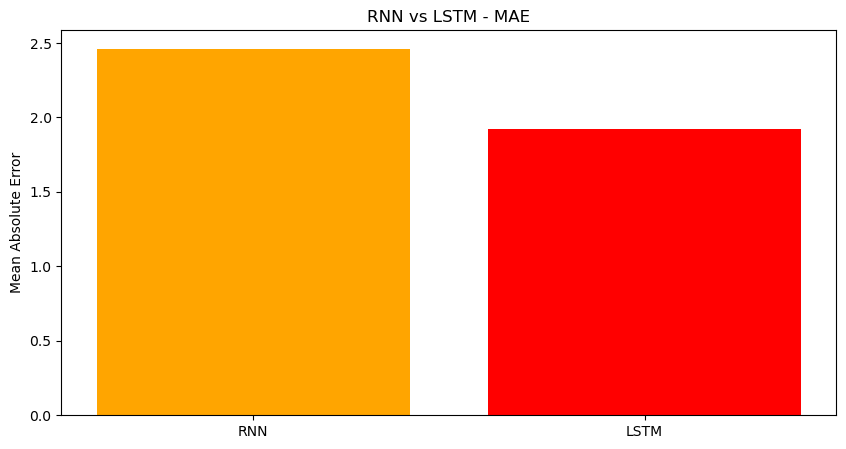

In [56]:
models = ["RNN", "LSTM"]
mae_values = [rnn_mae, lstm_mae]
plt.figure(figsize=(10, 5))
plt.bar(models, mae_values, color=["orange", "red"])
plt.title("RNN vs LSTM - MAE")
plt.ylabel("Mean Absolute Error")
plt.show()

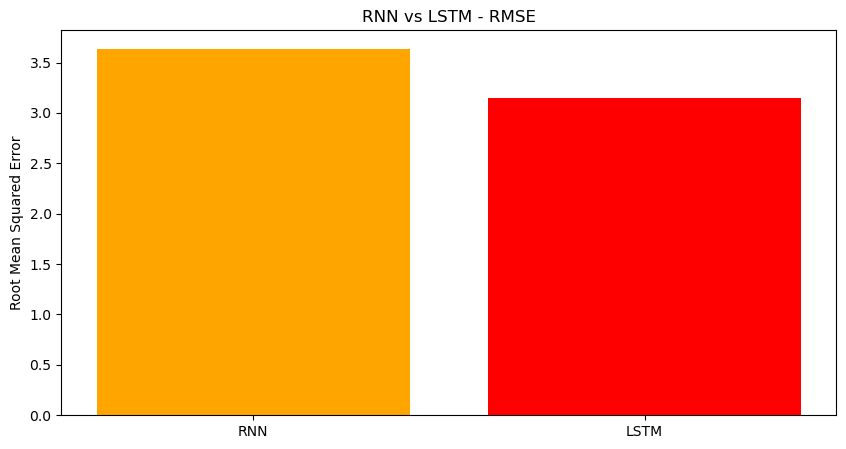

In [57]:
rmse_values = [rnn_rmse, lstm_rmse]
plt.figure(figsize=(10, 5))
plt.bar(models, rmse_values, color=["orange", "red"])
plt.title("RNN vs LSTM - RMSE")
plt.ylabel("Root Mean Squared Error")
plt.show()

In [59]:
tf.io.gfile.makedirs("models")
rnn_model.save("models/rnn_power_forecasting.keras")
print("RNN model saved successfully.")

RNN model saved successfully.


In [60]:
lstm_model.save("models/lstm_power_forecasting.keras")

In [61]:
import os

os.makedirs("models", exist_ok=True)

In [62]:
prediction_results = pd.DataFrame({
    "Actual": y_test_original.flatten(),
    "RNN_Predictions": rnn_predictions_original.flatten(),
    "LSTM_Predictions": lstm_predictions_original.flatten()
})
prediction_results.to_csv("prediction_results.csv", index=False)